# Shot Overview: LHD Shot 193772

This notebook loads already-cached diagnostics from `local/bh-molecule/` and builds a compact multi-panel discharge overview. It intentionally uses `load_cached_diag`, not `load_diag`, so missing cache files fail locally instead of triggering `igetfile` downloads.


## 1. Imports and Configuration

The cache path is kept explicit so the notebook uses the existing `local/bh-molecule/` structure exactly as-is.


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from lhd_data import load_cached_diag

SHOT = 193788
CACHE_DIR = Path("../local/bh-molecule")
DIAGNOSTICS = ["nbpwr_tot_temporal", "fircall", "thomson", "ha1", "ha2"]

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.35,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    }
)

print(f"Shot: {SHOT}")
print(f"Cache directory: {CACHE_DIR.resolve()}")


Shot: 193788
Cache directory: C:\Users\queezz\Dropbox\20-Code\2026-LHD\local\bh-molecule


## 2. Load Cached Diagnostics

Each diagnostic is loaded independently so a missing or malformed file does not stop the rest of the overview.


In [12]:
datasets = {}
failed = {}

for diag in DIAGNOSTICS:
    path = CACHE_DIR / f"{SHOT:06d}" / f"{diag}_000001.dat"
    try:
        if not path.exists():
            raise FileNotFoundError(f"Cached file is missing: {path}")
        datasets[diag] = load_cached_diag(diag, SHOT, cache_dir=CACHE_DIR)
        print(f"Loaded {diag}: {path}")
    except Exception as exc:
        failed[diag] = exc
        print(f"FAILED {diag}: {exc}")

print(f"\nLoaded diagnostics: {list(datasets)}")
if failed:
    print("Failed diagnostics:")
    for diag, exc in failed.items():
        print(f"  - {diag}: {exc}")


Loaded nbpwr_tot_temporal: ..\local\bh-molecule\193788\nbpwr_tot_temporal_000001.dat
Loaded fircall: ..\local\bh-molecule\193788\fircall_000001.dat
Loaded thomson: ..\local\bh-molecule\193788\thomson_000001.dat
Loaded ha1: ..\local\bh-molecule\193788\ha1_000001.dat
Loaded ha2: ..\local\bh-molecule\193788\ha2_000001.dat

Loaded diagnostics: ['nbpwr_tot_temporal', 'fircall', 'thomson', 'ha1', 'ha2']


## 3. Inspect Datasets

Signal names vary between diagnostics, so inspect the loaded `xarray.Dataset` objects before choosing variables for plotting.


In [13]:
for diag, ds in datasets.items():
    print("=" * 90)
    print(diag)
    print(ds)
    print("\nvariable names:")
    print(list(ds.data_vars))
    print("\ndimensions:")
    print(dict(ds.sizes))
    print("\ncoordinates:")
    for name, coord in ds.coords.items():
        print(f"  {name}: dims={coord.dims}, shape={coord.shape}, attrs={coord.attrs}")
    print()


nbpwr_tot_temporal
<xarray.Dataset> Size: 19MB
Dimensions:                 (time: 131072)
Coordinates:
  * time                    (time) float64 1MB 0.0001 0.0002 ... 13.11 13.11
Data variables: (12/17)
    Pport-through_t-nb-all  (time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Pport-through_r-nb-all  (time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Energy_NB1              (time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Port-Through_NB1        (time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Energy_NB2              (time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Port-Through_NB2        (time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                      ...
    Port-Through_NB5        (time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ISGas_NB1               (time) float64 1MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    ISGas_NB2               (time) float64 1MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    ISGas_NB3               (time) float64 1MB 1.0 1

## 4. Helper Functions

These utilities try to infer the time coordinate and useful signal variables from each dataset. They avoid hardcoding diagnostic-specific names except for broad keyword preferences such as `Te`, `n_e`, `Port-Through`, or `Halph`.


In [14]:
def find_time_coord(obj):
    """Return the most likely time coordinate name for a Dataset or DataArray."""
    names = list(getattr(obj, "coords", {})) + list(getattr(obj, "dims", ()))
    seen = []
    for name in names:
        if name not in seen:
            seen.append(name)

    for name in seen:
        lowered = str(name).lower()
        if lowered == "time" or lowered.startswith("time"):
            return name
    for name in seen:
        if "time" in str(name).lower():
            return name
    raise ValueError("No likely time coordinate found")


def safe_array(values):
    """Return values as a floating numpy array, preserving NaN for invalid points."""
    arr = np.asarray(values, dtype=float)
    return np.where(np.isfinite(arr), arr, np.nan)


def time_in_seconds(ds_or_da, time_name=None):
    """Extract time and convert millisecond-like axes to seconds."""
    time_name = time_name or find_time_coord(ds_or_da)
    t = safe_array(ds_or_da[time_name].values)
    finite = t[np.isfinite(t)]
    if finite.size and np.nanmax(np.abs(finite)) > 100:
        # Thomson time in this cache is stored in ms, while summary diagnostics are in s.
        t = t / 1000.0
    return t


def likely_signal_variables(ds, include=(), exclude=(), require_time=True, max_ndim=None):
    """Return numeric data variable names ranked by simple keyword matches."""
    include = tuple(word.lower() for word in include)
    exclude = tuple(word.lower() for word in exclude)

    try:
        time_name = find_time_coord(ds)
    except ValueError:
        time_name = None

    ranked = []
    for name, da in ds.data_vars.items():
        lowered = name.lower()
        if exclude and any(word in lowered for word in exclude):
            continue
        if require_time and time_name is not None and time_name not in da.dims:
            continue
        if max_ndim is not None and da.ndim > max_ndim:
            continue
        if not np.issubdtype(da.dtype, np.number):
            continue
        score = sum(word in lowered for word in include)
        if include and score == 0:
            continue
        ranked.append((score, name))

    ranked.sort(key=lambda item: (-item[0], item[1].lower()))
    return [name for _, name in ranked]


def first_existing_var(ds, candidates=(), include=(), exclude=()):
    """Prefer exact names, then fall back to keyword-ranked numeric variables."""
    lowered_lookup = {name.lower(): name for name in ds.data_vars}
    for candidate in candidates:
        match = lowered_lookup.get(candidate.lower())
        if match is not None:
            return match

    matches = likely_signal_variables(ds, include=include, exclude=exclude)
    return matches[0] if matches else None


def central_index(coord):
    """Return the index nearest the coordinate midpoint, or the positional midpoint."""
    values = safe_array(coord.values)
    if values.ndim == 1 and np.isfinite(values).any():
        center = 0.5 * (np.nanmin(values) + np.nanmax(values))
        return int(np.nanargmin(np.abs(values - center)))
    return coord.size // 2


def reduce_to_time_series(da, method="central"):
    """Reduce a DataArray to one value per time point."""
    time_name = find_time_coord(da)
    out = da

    for dim in list(out.dims):
        if dim == time_name:
            continue
        if method == "mean":
            out = out.mean(dim=dim, skipna=True)
        elif method == "central":
            idx = central_index(out[dim]) if dim in out.coords else out.sizes[dim] // 2
            out = out.isel({dim: idx})
        else:
            raise ValueError(f"Unknown reduction method: {method}")

    return time_in_seconds(out, time_name=time_name), safe_array(out.values)


def scale_signal(da, kind):
    """Convert common units to the units used in the overview labels."""
    units = str(da.attrs.get("units") or da.attrs.get("Unit") or "").lower()
    values = da.copy()

    if kind == "temperature" and "ev" in units and "kev" not in units:
        values = values / 1000.0
    elif kind == "density" and "10^16" in units:
        values = values / 1000.0
    elif kind == "density" and "e19" in units:
        values = values

    return values


def plot_series(ax, ds, var_name, label=None, kind=None, reduction="central", **kwargs):
    """Plot one inferred time series if the variable exists."""
    if ds is None or var_name is None:
        return False
    da = ds[var_name]
    if kind is not None:
        da = scale_signal(da, kind)
    t, y = reduce_to_time_series(da, method=reduction)
    ax.plot(t, y, label=label or var_name, **kwargs)
    return True


## 5. Thomson Coordinates and Shapes

Thomson data is often two-dimensional, usually time by radius or channel. For the overview time traces below, this notebook uses the central spatial channel instead of a spatial average. That keeps a core-like representative trend and avoids edge channels or invalid profile points dominating the trace. The 2D profile preview remains available below for checking the full spatial structure.


In [8]:
thomson = datasets.get("thomson")

if thomson is None:
    print("Thomson data was not loaded.")
else:
    print(thomson)
    print("\nCoordinates:")
    for name, coord in thomson.coords.items():
        values = safe_array(coord.values)
        finite = values[np.isfinite(values)]
        if finite.size:
            print(
                f"  {name}: dims={coord.dims}, shape={coord.shape}, "
                f"min={np.nanmin(finite):.4g}, max={np.nanmax(finite):.4g}"
            )
        else:
            print(f"  {name}: dims={coord.dims}, shape={coord.shape}")

    print("\nData variable shapes:")
    for name, da in thomson.data_vars.items():
        print(f"  {name}: dims={da.dims}, shape={da.shape}, units={da.attrs.get('units', '')}")


<xarray.Dataset> Size: 7MB
Dimensions:       (Time: 389, R: 140)
Coordinates:
  * Time          (Time) float64 3kB 0.35 33.68 67.02 ... 1.29e+04 1.293e+04
  * R             (R) float64 1kB 2.404e+03 2.43e+03 ... 4.863e+03 4.875e+03
Data variables: (12/15)
    Te            (Time, R) float64 436kB 45.0 11.0 0.0 86.0 ... 32.0 0.0 0.0
    dTe           (Time, R) float64 436kB 883.0 12.0 4.95e+04 ... 4.95e+04 14.0
    n_e           (Time, R) float64 436kB 7.0 78.0 640.0 ... -778.0 1.973e+03
    dn_e          (Time, R) float64 436kB 24.0 38.0 ... -1.002e+03 1.736e+05
    laser         (Time, R) float64 436kB 52.0 52.0 52.0 52.0 ... 55.0 55.0 55.0
    laser number  (Time, R) float64 436kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0
    ...            ...
    kcal          (Time, R) float64 436kB 2.601e+03 2.601e+03 ... 2.601e+03
    gcal1         (Time, R) float64 436kB 2.6e+03 2.6e+03 ... 2.6e+03 2.6e+03
    gcal2         (Time, R) float64 436kB 2.601e+03 2.601e+03 ... 2.601e+03
    gcal3       

## 6. Optional Thomson 2D Preview

Use this preview to verify whether the central-channel time trace is a reasonable summary for this shot.


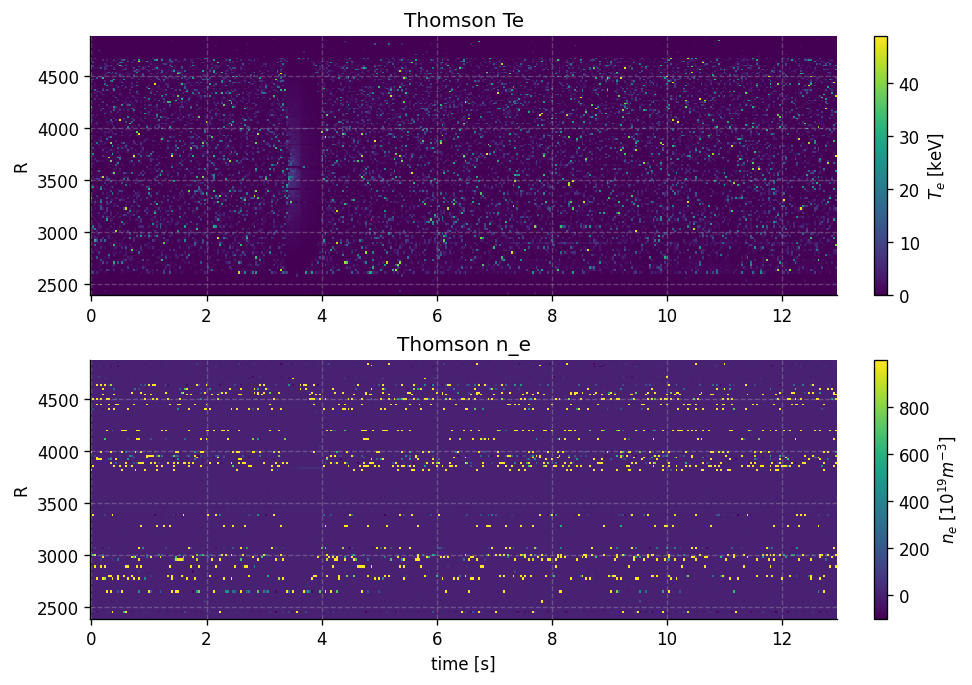

In [15]:
if thomson is not None:
    te_name = first_existing_var(thomson, candidates=("Te",), include=("te",), exclude=("dte",))
    ne_name = first_existing_var(thomson, candidates=("n_e", "ne"), include=("n_e", "ne"), exclude=("dn", "error"))

    preview_vars = [("Te", te_name, "temperature", r"$T_e$ [keV]"), ("ne", ne_name, "density", r"$n_e$ [$10^{19} m^{-3}$]")]
    preview_vars = [item for item in preview_vars if item[1] is not None and thomson[item[1]].ndim == 2]

    if preview_vars:
        fig, axes = plt.subplots(len(preview_vars), 1, figsize=(8, 2.8 * len(preview_vars)), constrained_layout=True)
        axes = np.atleast_1d(axes)
        time_name = find_time_coord(thomson)
        t = time_in_seconds(thomson, time_name=time_name)

        for ax, (_, var_name, kind, label) in zip(axes, preview_vars):
            da = scale_signal(thomson[var_name], kind)
            spatial_dims = [dim for dim in da.dims if dim != time_name]
            spatial_dim = spatial_dims[0]
            x = safe_array(da[spatial_dim].values) if spatial_dim in da.coords else np.arange(da.sizes[spatial_dim])
            z = safe_array(da.transpose(time_name, spatial_dim).values)
            mesh = ax.pcolormesh(t, x, z.T, shading="auto")
            ax.set_ylabel(spatial_dim)
            ax.set_title(f"Thomson {var_name}")
            fig.colorbar(mesh, ax=ax, label=label)
        axes[-1].set_xlabel("time [s]")
    else:
        print("No 2D Thomson Te/ne variables found for preview.")


## 7. Four-Panel Shot Overview


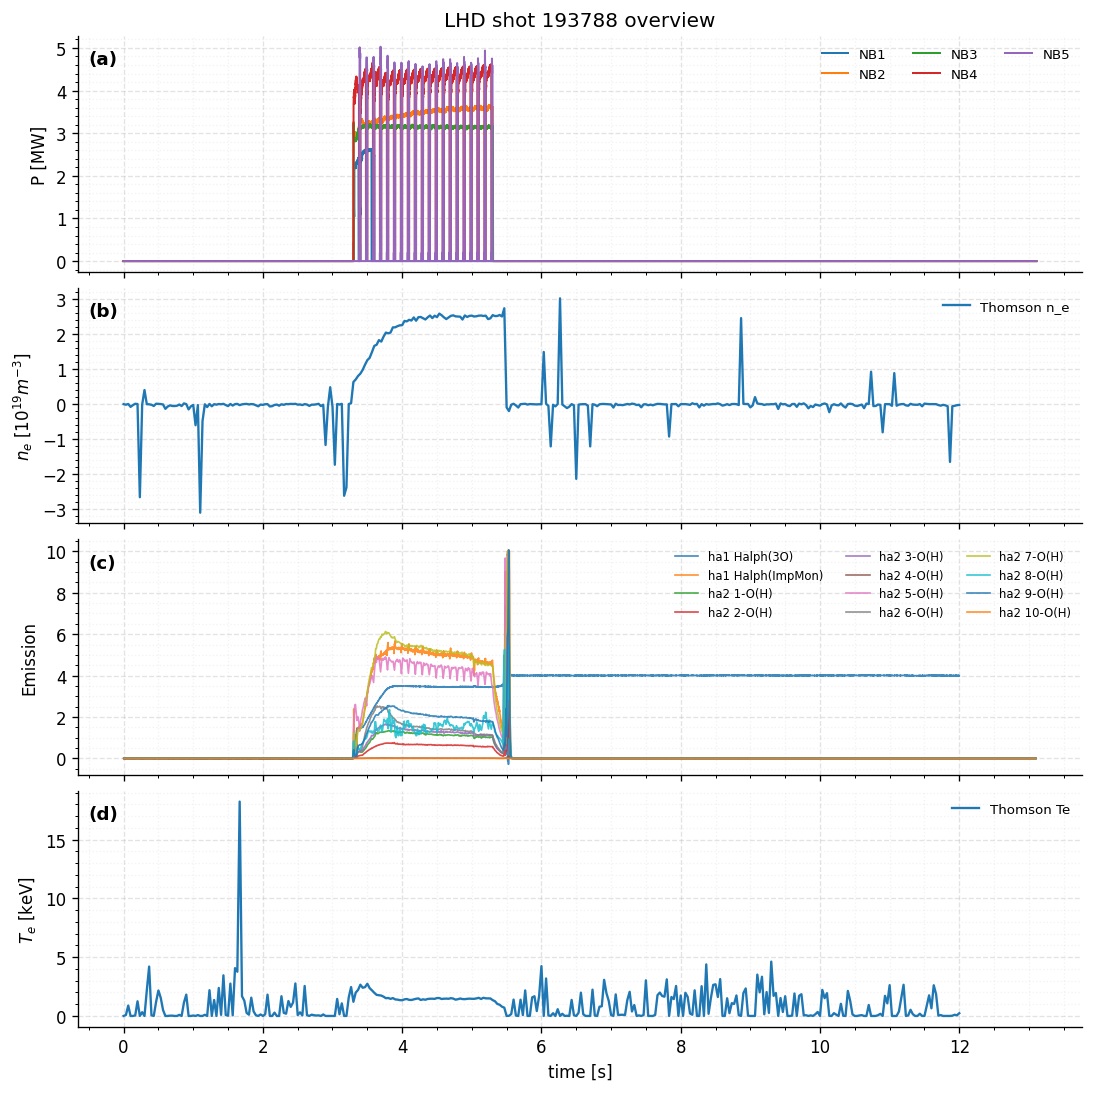

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True, constrained_layout=True)
ax_nbi, ax_ne, ax_ha, ax_te = axes

# (a) NBI powers: prefer individual port-through channels, then fall back to MW power variables.
nbi = datasets.get("nbpwr_tot_temporal")
if nbi is not None:
    nbi_vars = likely_signal_variables(
        nbi,
        include=("port-through_nb",),
        exclude=("all", "energy", "isgas"),
        max_ndim=1,
    )
    if not nbi_vars:
        nbi_vars = likely_signal_variables(nbi, include=("port", "p"), exclude=("energy", "isgas", "all"), max_ndim=1)
    for name in nbi_vars:
        plot_series(ax_nbi, nbi, name, label=name.replace("Port-Through_", ""), linewidth=1.2)
else:
    ax_nbi.text(0.5, 0.5, "NBI data unavailable", transform=ax_nbi.transAxes, ha="center", va="center")
ax_nbi.set_ylabel("P [MW]")
ax_nbi.set_title(f"LHD shot {SHOT} overview")
if ax_nbi.lines:
    ax_nbi.legend(loc="upper right", ncols=min(3, len(ax_nbi.lines)), fontsize=8)

# (b) Electron density: prefer Thomson n_e, otherwise FIR ne_bar.
thomson = datasets.get("thomson")
fircall = datasets.get("fircall")
plotted_density = False
if thomson is not None:
    ne_name = first_existing_var(thomson, candidates=("n_e", "ne"), include=("n_e", "ne"), exclude=("dn", "error"))
    plotted_density = plot_series(ax_ne, thomson, ne_name, label=f"Thomson {ne_name}", kind="density", reduction="central", linewidth=1.4)
if not plotted_density and fircall is not None:
    ne_name = first_existing_var(fircall, include=("ne_bar", "ne"), exclude=("nl", "peak"))
    plotted_density = plot_series(ax_ne, fircall, ne_name, label=f"FIR {ne_name}", kind="density", linewidth=1.4)
if not plotted_density:
    ax_ne.text(0.5, 0.5, "Density data unavailable", transform=ax_ne.transAxes, ha="center", va="center")
ax_ne.set_ylabel(r"$n_e$ [$10^{19} m^{-3}$]")
if ax_ne.lines:
    ax_ne.legend(loc="upper right", fontsize=8)

# (c) Balmer emission: plot available H-alpha-like channels from ha1 and H channels from ha2.
for diag in ("ha1", "ha2"):
    ds = datasets.get(diag)
    if ds is None:
        continue
    if diag == "ha1":
        ha_vars = likely_signal_variables(ds, include=("halph", "halpha"), exclude=("hei",), max_ndim=1)
    else:
        ha_vars = [name for name in ds.data_vars if "(h)" in name.lower() and "he" not in name.lower()]
    for name in ha_vars:
        plot_series(ax_ha, ds, name, label=f"{diag} {name}", linewidth=1.0, alpha=0.85)
if not ax_ha.lines:
    ax_ha.text(0.5, 0.5, "Balmer data unavailable", transform=ax_ha.transAxes, ha="center", va="center")
ax_ha.set_ylabel("Emission")
if ax_ha.lines:
    ax_ha.legend(loc="upper right", ncols=3, fontsize=7)

# (d) Electron temperature from Thomson.
plotted_te = False
if thomson is not None:
    te_name = first_existing_var(thomson, candidates=("Te",), include=("te",), exclude=("dte", "error"))
    plotted_te = plot_series(ax_te, thomson, te_name, label=f"Thomson {te_name}", kind="temperature", reduction="central", linewidth=1.4)
if not plotted_te:
    ax_te.text(0.5, 0.5, "Temperature data unavailable", transform=ax_te.transAxes, ha="center", va="center")
ax_te.set_ylabel(r"$T_e$ [keV]")
ax_te.set_xlabel("time [s]")
if ax_te.lines:
    ax_te.legend(loc="upper right", fontsize=8)

for label, ax in zip(("(a)", "(b)", "(c)", "(d)"), axes):
    ax.text(0.01, 0.88, label, transform=ax.transAxes, fontsize=11, fontweight="bold")
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.35, linestyle="--")
    ax.grid(True, which="minor", alpha=0.15, linestyle=":")

plt.show()
